
# SECTION 1: ENVIRONMENT SETUP

# ### 1.1 Import Required Libraries

In [5]:
# Core data manipulation
import pandas as pd
import numpy as np
from datetime import datetime
!pip install xgboost

import sys
!{sys.executable} -m pip install lightgbm

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import RobustScaler, StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                            confusion_matrix, classification_report, roc_auc_score,
                            roc_curve, precision_recall_curve)
#
# Models
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
import xgboost as xgb
import lightgbm as lgb

# Model persistence
import joblib
import pickle

# Utilities
import warnings
warnings.filterwarnings('ignore')
from tqdm import tqdm
import os

# Set random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


# ### 1.2 Configure Display Settings

In [6]:
# Pandas display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

# Matplotlib settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

# Create output directories
os.makedirs('models', exist_ok=True)
os.makedirs('plots', exist_ok=True)
os.makedirs('reports', exist_ok=True)


# SECTION 2: DATA LOADING & VALIDATION

# ### 2.1 Load Satellite Data

In [7]:



class DataLoader:
    """Class to handle data loading operations"""
    
    def __init__(self, file_path):
        self.file_path = file_path
        self.data = None
        self.original_shape = None
        
    def load_data(self):
        """Load data from CSV file"""
        try:
            self.data = pd.read_csv(self.file_path)
            self.original_shape = self.data.shape
            print(f"✅ Data loaded successfully!")
            print(f"   Shape: {self.data.shape}")
            print(f"   Columns: {list(self.data.columns)}")
            return self.data
        except FileNotFoundError:
            print(f"❌ File not found: {self.file_path}")
            return None
        except Exception as e:
            print(f"❌ Error loading data: {e}")
            return None
    
    def get_data_summary(self):
        """Get comprehensive data summary"""
        if self.data is None:
            return None
        
        summary = {
            'shape': self.data.shape,
            'columns': list(self.data.columns),
            'dtypes': self.data.dtypes.to_dict(),
            'missing_values': self.data.isnull().sum().to_dict(),
            'missing_percentage': (self.data.isnull().sum() / len(self.data) * 100).to_dict()
        }
        return summary

# Load your data
data_loader = DataLoader('fire_dataset.csv')   # ✅ CHANGE HERE
df_raw = data_loader.load_data()

if df_raw is not None:
    summary = data_loader.get_data_summary()
    print("\n📊 Data Summary:")
    print(f"   Total samples: {summary['shape'][0]}")
    print(f"   Total features: {summary['shape'][1]}")
    print(f"   Missing values: {sum(summary['missing_values'].values())}")

✅ Data loaded successfully!
   Shape: (552312, 15)
   Columns: ['latitude', 'longitude', 'bright_ti4', 'scan', 'track', 'acq_date', 'acq_time', 'satellite', 'instrument', 'confidence', 'version', 'bright_ti5', 'frp', 'daynight', 'type']

📊 Data Summary:
   Total samples: 552312
   Total features: 15
   Missing values: 0


### 2.2 Data Validation Report

In [8]:
def generate_data_quality_report(df):
    """Generate comprehensive data quality report"""
    
    report = {
        'total_rows': len(df),
        'total_columns': len(df.columns),
        'duplicate_rows': df.duplicated().sum(),
        'memory_usage': df.memory_usage(deep=True).sum() / 1024**2,  # MB
        'column_analysis': {}
    }
    
    for col in df.columns:
        col_info = {
            'dtype': str(df[col].dtype),
            'unique_values': df[col].nunique(),
            'missing_count': df[col].isnull().sum(),
            'missing_pct': df[col].isnull().sum() / len(df) * 100
        }
        
        if df[col].dtype in ['float64', 'int64']:
            col_info['min'] = df[col].min()
            col_info['max'] = df[col].max()
            col_info['mean'] = df[col].mean()
            col_info['std'] = df[col].std()
        
        report['column_analysis'][col] = col_info
    
    return report

if df_raw is not None:
    quality_report = generate_data_quality_report(df_raw)
    
    print("="*60)
    print("📋 DATA QUALITY REPORT")
    print("="*60)
    print(f"Total Rows: {quality_report['total_rows']:,}")
    print(f"Total Columns: {quality_report['total_columns']}")
    print(f"Duplicate Rows: {quality_report['duplicate_rows']:,}")
    print(f"Memory Usage: {quality_report['memory_usage']:.2f} MB")
    print("\n📊 Column Analysis:")
    
    for col, info in quality_report['column_analysis'].items():
        print(f"\n   {col}:")
        print(f"      Type: {info['dtype']}")
        print(f"      Missing: {info['missing_count']} ({info['missing_pct']:.1f}%)")
        if 'min' in info:
            print(f"      Range: [{info['min']:.2f}, {info['max']:.2f}]")

📋 DATA QUALITY REPORT
Total Rows: 552,312
Total Columns: 15
Duplicate Rows: 0
Memory Usage: 72.69 MB

📊 Column Analysis:

   latitude:
      Type: float64
      Missing: 0 (0.0%)
      Range: [8.11, 34.68]

   longitude:
      Type: float64
      Missing: 0 (0.0%)
      Range: [68.51, 97.08]

   bright_ti4:
      Type: float64
      Missing: 0 (0.0%)
      Range: [208.00, 367.00]

   scan:
      Type: float64
      Missing: 0 (0.0%)
      Range: [0.32, 0.80]

   track:
      Type: float64
      Missing: 0 (0.0%)
      Range: [0.36, 0.78]

   acq_date:
      Type: str
      Missing: 0 (0.0%)

   acq_time:
      Type: int64
      Missing: 0 (0.0%)
      Range: [536.00, 2159.00]

   satellite:
      Type: str
      Missing: 0 (0.0%)

   instrument:
      Type: str
      Missing: 0 (0.0%)

   confidence:
      Type: str
      Missing: 0 (0.0%)

   version:
      Type: int64
      Missing: 0 (0.0%)
      Range: [2.00, 2.00]

   bright_ti5:
      Type: float64
      Missing: 0 (0.0%)
      R


# SECTION 3: EXPLORATORY DATA ANALYSIS


# ### 3.1 Statistical Summary

📈 STATISTICAL SUMMARY

Numerical Features:
        latitude  longitude  bright_ti4       scan      track   acq_time    version  bright_ti5        frp       type
count 552312.000 552312.000  552312.000 552312.000 552312.000 552312.000 552312.000  552312.000 552312.000 552312.000
mean      22.819     80.787     331.504      0.452      0.467   1113.441      2.000     301.231      6.096      0.251
std        4.971      5.278      16.672      0.080      0.108    563.033      0.000      10.010     13.677      0.667
min        8.110     68.508     208.000      0.320      0.360    536.000      2.000     150.000      0.000      0.000
25%       19.317     76.989     318.850      0.390      0.370    735.000      2.000     294.250      1.950      0.000
50%       22.855     79.998     335.350      0.430      0.430    807.000      2.000     301.930      3.530      0.000
75%       25.940     83.735     342.150      0.500      0.540   1932.000      2.000     307.860      6.210      0.000
max       34.

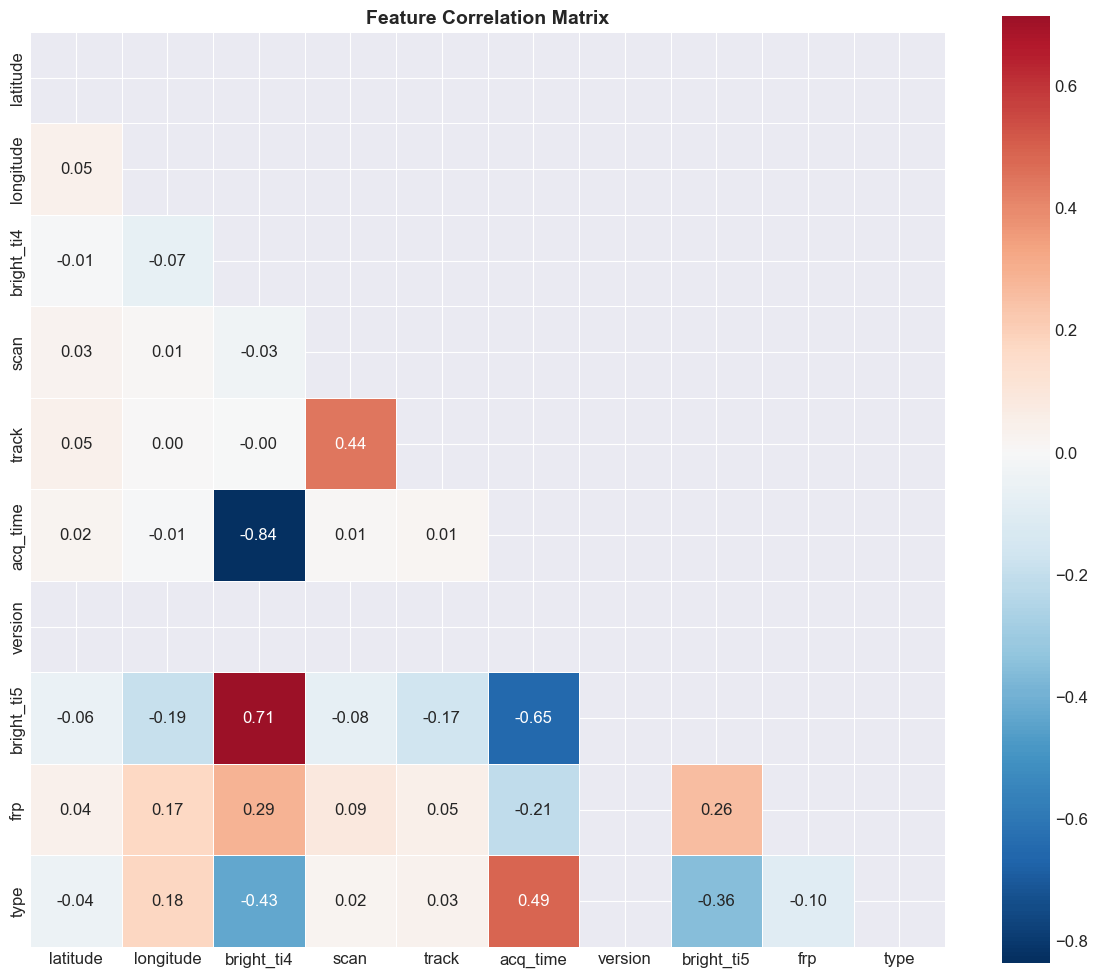

In [9]:
class DataAnalyzer:
    """Class for comprehensive data analysis"""
    
    def __init__(self, df):
        self.df = df
        self.numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
        self.categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
    
    def statistical_summary(self):
        """Generate statistical summary"""
        print("="*60)
        print("📈 STATISTICAL SUMMARY")
        print("="*60)
        print("\nNumerical Features:")
        print(self.df[self.numerical_cols].describe().to_string())
        
        if self.categorical_cols:
            print("\nCategorical Features:")
            for col in self.categorical_cols:
                print(f"\n{col}:")
                print(self.df[col].value_counts().head().to_string())
    
    def correlation_analysis(self):
        """Perform correlation analysis"""
        corr_matrix = self.df[self.numerical_cols].corr()
        
        # Create correlation heatmap
        fig, ax = plt.subplots(figsize=(12, 10))
        mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
        sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', 
                   cmap='RdBu_r', center=0, square=True, 
                   linewidths=0.5, ax=ax)
        ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.savefig('plots/correlation_matrix.png', dpi=150, bbox_inches='tight')
        plt.show()
        
        return corr_matrix

if df_raw is not None:
    analyzer = DataAnalyzer(df_raw)
    analyzer.statistical_summary()
    corr_matrix = analyzer.correlation_analysis()

### Step 4.1: DataPreprocessing

In [14]:
class DataPreprocessor:
    """Professional data preprocessing pipeline"""
    
    def __init__(self, df):
        self.df = df.copy()
        self.preprocessing_log = []
        
    def log_step(self, message):
        self.preprocessing_log.append(message)
        print(f"   ✓ {message}")
    
    def clean_missing_values(self, threshold=0.3):
        initial_shape = self.df.shape
        missing_pct = self.df.isnull().sum() / len(self.df)
        cols_to_drop = missing_pct[missing_pct > threshold].index.tolist()
        if cols_to_drop:
            self.df = self.df.drop(columns=cols_to_drop)
            self.log_step(f"Dropped {len(cols_to_drop)} columns with >{threshold*100}% missing values")
        
        for col in self.df.columns:
            if self.df[col].isnull().any():
                if self.df[col].dtype in ['float64', 'int64']:
                    self.df[col].fillna(self.df[col].median(), inplace=True)
                else:
                    self.df[col].fillna(self.df[col].mode()[0], inplace=True)
        
        self.log_step(f"Data shape: {initial_shape} → {self.df.shape}")
        return self  # Return self for chaining
    
    def clean_acq_time(self):
        if 'acq_time' in self.df.columns:
            self.df['acq_time'] = pd.to_numeric(self.df['acq_time'], errors='coerce')
            self.log_step("Cleaned 'acq_time' column")
        return self
    
    def drop_unnecessary_columns(self):
        cols_to_drop = ['satellite', 'instrument', 'version', 'acq_date']
        existing_cols = [col for col in cols_to_drop if col in self.df.columns]
        if existing_cols:
            self.df = self.df.drop(columns=existing_cols)
            self.log_step(f"Dropped columns: {existing_cols}")
        return self
    
    def encode_categorical(self):
        categorical_cols = self.df.select_dtypes(include=['object']).columns
        
        for col in categorical_cols:
            if col == 'confidence':
                confidence_map = {'n': 1, 'h': 2, 'l': 0}
                self.df[col] = self.df[col].astype(str).str.lower().map(confidence_map).fillna(1)
                self.log_step(f"Encoded '{col}' column (n=1, h=2, l=0)")
            elif col == 'daynight':
                daynight_map = {'D': 1, 'N': 0}
                self.df[col] = self.df[col].map(daynight_map).fillna(1)
                self.log_step(f"Encoded '{col}' column (D=1, N=0)")
            elif col not in ['acq_date', 'satellite', 'instrument']:
                le = LabelEncoder()
                self.df[col] = le.fit_transform(self.df[col].astype(str))
                self.log_step(f"Encoded '{col}' column with LabelEncoder")
        return self
    
    def create_target_variable(self, frp_col='frp', thresholds=[0, 5]):
        self.df['fire_severity'] = 0
        self.df.loc[self.df[frp_col] > thresholds[0], 'fire_severity'] = 1
        self.df.loc[self.df[frp_col] > thresholds[1], 'fire_severity'] = 2
        self.log_step(f"Created target 'fire_severity' (0=No, 1=Low, 2=High)")
        return self
    
    def get_preprocessing_report(self):
        report = {
            'final_shape': self.df.shape,
            'columns': list(self.df.columns),
            'preprocessing_steps': self.preprocessing_log,
            'target_distribution': self.df['fire_severity'].value_counts().to_dict() if 'fire_severity' in self.df.columns else None
        }
        return report

# Apply preprocessing
print("="*60)
print("🔄 STARTING PREPROCESSING PIPELINE")
print("="*60)

preprocessor = DataPreprocessor(df_raw)
preprocessor.clean_missing_values(threshold=0.3)
preprocessor.clean_acq_time()
preprocessor.drop_unnecessary_columns()
preprocessor.encode_categorical()
preprocessor.create_target_variable()

df_cleaned = preprocessor.df

print("\n" + "="*60)
print("📋 PREPROCESSING REPORT")
print("="*60)
report = preprocessor.get_preprocessing_report()
print(f"Final Shape: {report['final_shape']}")
print(f"\nTarget Distribution:")
print(pd.Series(report['target_distribution']))
print(f"\nFinal Columns:\n{report['columns']}")

🔄 STARTING PREPROCESSING PIPELINE
   ✓ Data shape: (552312, 15) → (552312, 15)
   ✓ Cleaned 'acq_time' column
   ✓ Dropped columns: ['satellite', 'instrument', 'version', 'acq_date']
   ✓ Encoded 'confidence' column (n=1, h=2, l=0)
   ✓ Encoded 'daynight' column (D=1, N=0)
   ✓ Created target 'fire_severity' (0=No, 1=Low, 2=High)

📋 PREPROCESSING REPORT
Final Shape: (552312, 12)

Target Distribution:
1    366060
2    186231
0        21
dtype: int64

Final Columns:
['latitude', 'longitude', 'bright_ti4', 'scan', 'track', 'acq_time', 'confidence', 'bright_ti5', 'frp', 'daynight', 'type', 'fire_severity']


# Feature Engineering

In [15]:
class FeatureEngineer:
    """Advanced feature engineering pipeline"""
    
    def __init__(self, df):
        self.df = df.copy()
        self.new_features = []
    
    def add_temperature_features(self):
        self.df['temp_diff'] = self.df['bright_ti4'] - self.df['bright_ti5']
        self.df['temp_ratio'] = self.df['bright_ti4'] / (self.df['bright_ti5'] + 0.01)
        self.new_features.extend(['temp_diff', 'temp_ratio'])
        print(f"✓ Added temp_diff, temp_ratio")
        return self
    
    def add_fire_intensity_features(self):
        self.df['fire_risk_score'] = (self.df['bright_ti4'] - 300) * 0.4 + self.df['temp_diff'] * 0.3 + np.log1p(self.df['frp']) * 0.3
        self.df['frp_per_area'] = self.df['frp'] / (self.df['scan'] * self.df['track'] + 0.01)
        self.new_features.extend(['fire_risk_score', 'frp_per_area'])
        print(f"✓ Added fire_risk_score, frp_per_area")
        return self
    
    def get_feature_list(self):
        return self.new_features

# Apply feature engineering
print("="*60)
print("🔧 FEATURE ENGINEERING")
print("="*60)

engineer = FeatureEngineer(df_cleaned)
engineer.add_temperature_features().add_fire_intensity_features()
df_features = engineer.df

print(f"\n✅ Final shape: {df_features.shape}")
print(f"New features: {engineer.get_feature_list()}")
print(f"\nColumns:\n{df_features.columns.tolist()}")

🔧 FEATURE ENGINEERING
✓ Added temp_diff, temp_ratio
✓ Added fire_risk_score, frp_per_area

✅ Final shape: (552312, 16)
New features: ['temp_diff', 'temp_ratio', 'fire_risk_score', 'frp_per_area']

Columns:
['latitude', 'longitude', 'bright_ti4', 'scan', 'track', 'acq_time', 'confidence', 'bright_ti5', 'frp', 'daynight', 'type', 'fire_severity', 'temp_diff', 'temp_ratio', 'fire_risk_score', 'frp_per_area']


# Model Training

In [16]:
# Prepare features and target
feature_cols = ['latitude', 'longitude', 'bright_ti4', 'bright_ti5', 'scan', 'track', 
                'acq_time', 'confidence', 'daynight', 'temp_diff', 'temp_ratio', 
                'fire_risk_score', 'frp_per_area']

X = df_features[feature_cols]
y = df_features['fire_severity']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale features
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set: {X_test.shape[0]} samples")
print(f"Features: {X_train.shape[1]}")

Training set: 441849 samples
Testing set: 110463 samples
Features: 13


# Train Random Forest Model

In [18]:
# Train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)

# Predict and evaluate
y_pred_rf = rf_model.predict(X_test_scaled)
accuracy_rf = accuracy_score(y_test, y_pred_rf)

print(f"Random Forest Accuracy: {accuracy_rf:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=['No Fire', 'Low Fire', 'High Fire']))

Random Forest Accuracy: 0.9954

Classification Report:
              precision    recall  f1-score   support

     No Fire       1.00      0.75      0.86         4
    Low Fire       0.99      1.00      1.00     73212
   High Fire       1.00      0.99      0.99     37247

    accuracy                           1.00    110463
   macro avg       1.00      0.91      0.95    110463
weighted avg       1.00      1.00      1.00    110463



# Save Model & Scaler

In [19]:
# Save model and scaler
joblib.dump(rf_model, 'fire_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(feature_cols, 'feature_columns.pkl')

print("✅ Model saved: fire_model.pkl")
print("✅ Scaler saved: scaler.pkl")
print("✅ Features saved: feature_columns.pkl")

✅ Model saved: fire_model.pkl
✅ Scaler saved: scaler.pkl
✅ Features saved: feature_columns.pkl


# Prediction Function

In [20]:
def predict_fire(lat, lon, ti4, ti5, scan, track, acq_time, confidence, daynight):
    # Calculate features
    temp_diff = ti4 - ti5
    temp_ratio = ti4 / (ti5 + 0.01)
    fire_risk = (ti4 - 300) * 0.4 + temp_diff * 0.3
    frp_per_area = 1 / (scan * track + 0.01)  # Default FRP=1
    
    # Create input
    input_data = pd.DataFrame([[lat, lon, ti4, ti5, scan, track, acq_time, 
                                confidence, daynight, temp_diff, temp_ratio, 
                                fire_risk, frp_per_area]], columns=feature_cols)
    
    # Scale and predict
    input_scaled = scaler.transform(input_data)
    pred = rf_model.predict(input_scaled)[0]
    prob = rf_model.predict_proba(input_scaled)[0]
    
    severity = {0: "No Fire 🟢", 1: "Low Fire 🟡", 2: "High Fire 🔴"}
    return severity[pred], max(prob)

# Test
status, conf = predict_fire(18.24, 83.95, 333.71, 296.66, 0.33, 0.56, 702, 1, 1)
print(f"Prediction: {status}")
print(f"Confidence: {conf:.2%}")

Prediction: Low Fire 🟡
Confidence: 99.65%


# visualization

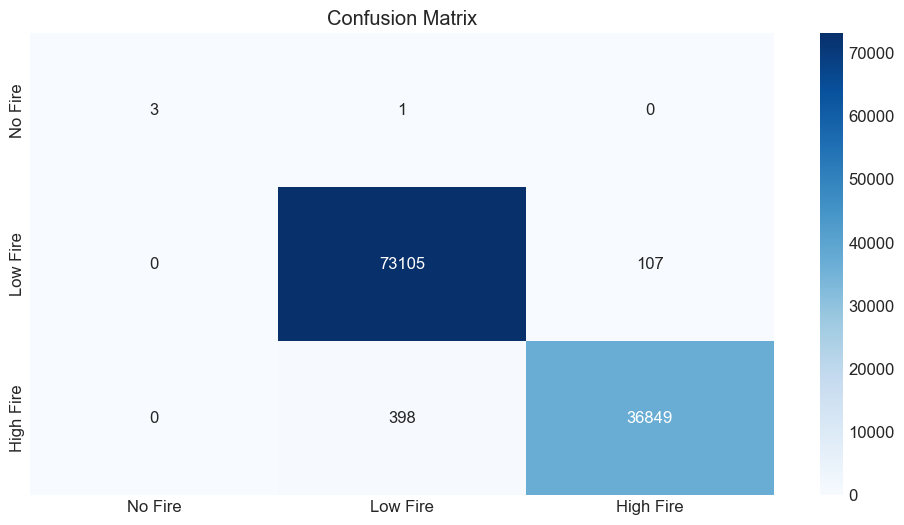

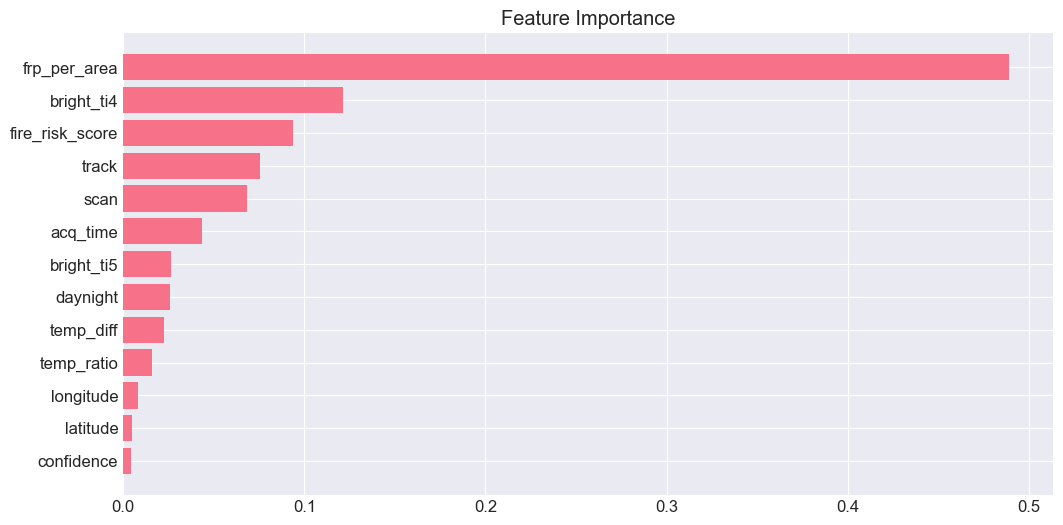

Accuracy: 0.9954
              precision    recall  f1-score   support

     No Fire       1.00      0.75      0.86         4
    Low Fire       0.99      1.00      1.00     73212
   High Fire       1.00      0.99      0.99     37247

    accuracy                           1.00    110463
   macro avg       1.00      0.91      0.95    110463
weighted avg       1.00      1.00      1.00    110463



In [23]:
# Features list 
features = ['latitude', 'longitude', 'bright_ti4', 'bright_ti5', 'scan', 'track', 
            'acq_time', 'confidence', 'daynight', 'temp_diff', 'temp_ratio', 
            'fire_risk_score', 'frp_per_area']

# Get predictions
y_pred = rf_model.predict(X_test_scaled)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Fire', 'Low Fire', 'High Fire'],
            yticklabels=['No Fire', 'Low Fire', 'High Fire'])
plt.title('Confusion Matrix')
plt.show()

# Feature Importance
imp = pd.DataFrame({'Feature': features, 'Importance': rf_model.feature_importances_})
imp = imp.sort_values('Importance', ascending=True)
plt.barh(imp['Feature'], imp['Importance'])
plt.title('Feature Importance')
plt.show()

# Results
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred, target_names=['No Fire', 'Low Fire', 'High Fire']))